# Round 3: the two quarters side by side, as named steps

**Week 2, Monday. Notebook 3 of 3, round 3 of the morning.**

> "Be ready to explain why each query is written the way it is." Anand Iyer, finance controller, Kalpa Retail,
> on the analyst who will audit the suite line by line

Round 2 put every leaf on the sheet per segment and quarter, with honest division. Anand's real
question is Week 1's: which branch moved from Q1 to Q2, in which segment. That needs the two
quarters on one row, and a query the analyst can read top to bottom. A CTE, a `WITH` block, is a
named step: each block computes one thing and the last `SELECT` lines them up.

> **Kavya's review.** An average is a sum over a count. Before you quote one, tell me who is in the
> count, and who quietly is not.

Four levels: a query inside a query, two quarters as named steps, an average that skips people
without saying so, and the honest average for every segment.

**Setup.** The helper, the warehouse, and the named queries from
`../sql/C2_W02_D01_03_quarters_STUDENT.sql`.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import re
SQL_DIR = kit.data_dir().parent / "sql"

def blocks(stem):
    """Every named block of a .sql file in ../sql/, keyed by the name on its '-- name:' line."""
    text = (SQL_DIR / f"C2_W02_D01_{stem}_STUDENT.sql").read_text(encoding="utf-8")
    parts = re.split(r"^-- name: (\w+)\s*$", text, flags=re.M)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

def statements(block):
    """A block's statements, comments removed, for a block that runs more than one."""
    bare = "\n".join(l for l in block.splitlines() if not l.strip().startswith("--"))
    return [s.strip() for s in bare.split(";") if s.strip()]

Q = blocks("03_quarters")
print(len(Q), "named queries read")

7 named queries read


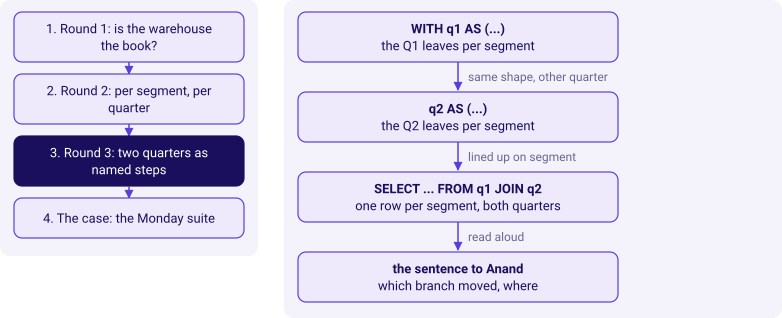

In [2]:
kit.side_by_side(
    kit.ladder(['Round 1: is the warehouse the book?', 'Round 2: per segment, per quarter', 'Round 3: two quarters as named steps', 'The case: the Monday suite'], lit=2, show=False),
    kit.vflow(["WITH q1 AS (...)\nthe Q1 leaves per segment",
               "q2 AS (...)\nthe Q2 leaves per segment",
               "SELECT ... FROM q1 JOIN q2\none row per segment, both quarters",
               "the sentence to Anand\nwhich branch moved, where"],
              edges=["same shape, other quarter", "lined up on segment", "read aloud"], show=False),
)

## 1. A query inside a query

Anand's first question on any split is how much of the book each part carries. The share needs the
total as its denominator, and the total is itself a query. Written in brackets inside the first,
it is a subquery.

**Predict before you run.** What share of the two quarters' revenue does Business carry:
a) about a quarter; b) about half; c) about 90 percent; d) about 99 percent?

In [3]:
print(Q["r3_share_subquery"])

-- The question: what share of the two quarters' revenue does each segment carry?
-- The total sits in a subquery, a query inside a query.
SELECT c.segment,
       sum(o.amount) AS revenue,
       round(100 * sum(o.amount) / (SELECT sum(amount) FROM orders), 1) AS share_pct
FROM   orders o
JOIN   customers c USING (customer_id)
GROUP  BY c.segment
ORDER  BY revenue DESC;


segment,revenue,share_pct
Business,"196,599,040",99.1
Retail-Plus,"999,150",0.5
Retail-Core,"739,320",0.4
Student,"62,490",0


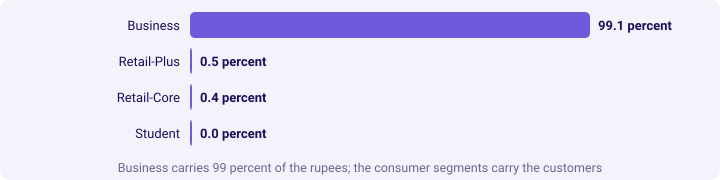

In [4]:
share = kit.sql(Q["r3_share_subquery"])
kit.sql_table(Q["r3_share_subquery"], caption="Each segment's share of Rs 19.84 crore, the total from a subquery")
kit.bars([(r["segment"], float(r["share_pct"])) for r in share], fmt=lambda v: f"{v:.1f} percent",
         title="Business carries 99 percent of the rupees; the consumer segments carry the customers")
kit.check("the shares add to 100 percent", abs(sum(float(r["share_pct"]) for r in share) - 100) < 0.2)

**What happened.** The answer is d: 99.1 percent. The consumer segments hold most of the
customers and under one percent of the rupees, which is why Week 1 read the frequency branch per
segment and never from the total. A subquery works, and it hides its step in the middle of a line;
the next level names the steps instead.

## 2. Two quarters as named steps

**Predict before you run.** The query below has three steps. What can the final `SELECT` see:
a) only `q2`; b) `q1` and `q2`, and the tables; c) only the tables; d) only `q1`?

In [5]:
print(Q["r3_two_quarters"])

-- The question: which branch of the tree moved in each segment from Q1 to Q2?
-- Step q1 and step q2 compute the same leaves for one quarter each; the last step lines them up.
WITH q1 AS (
    SELECT c.segment,
           count(DISTINCT o.customer_id) AS customers,
           count(*)                      AS orders,
           sum(o.amount)                 AS revenue
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  o.quarter = 'Q1'
    GROUP  BY c.segment
),
q2 AS (
    SELECT c.segment,
           count(DISTINCT o.customer_id) AS customers,
           count(*)                      AS orders,
           sum(o.amount)                 AS revenue
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  o.quarter = 'Q2'
    GROUP  BY c.segment
)
SELECT segment,
       q1.customers AS q1_customers,
       q2.customers AS q2_customers,
       round(q1.orders::numeric / q1.customers, 2) AS q1_orders_per_customer,
       round(q2.orders::numeric / q2.

segment,q1_customers,q2_customers,q1_orders_per_customer,q2_orders_per_customer,q1_revenue_per_order,q2_revenue_per_order,revenue_change_pct
Business,36,35,2.69,2.6,"1,020,767","1,072,358",-1.4
Retail-Core,102,96,1.95,2.01,1875,1898,-1.8
Retail-Plus,91,76,2.36,1.84,2725,2953,-29.4
Student,15,20,1.8,1.9,990,941,33.9


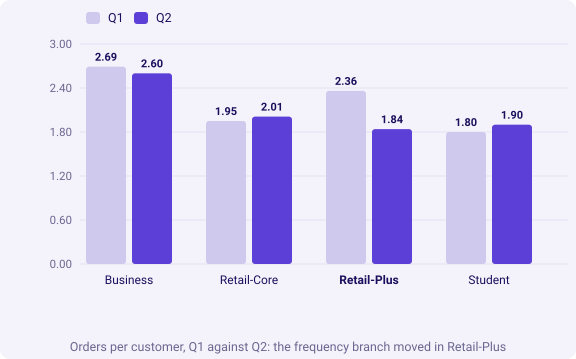

In [6]:
two = kit.sql(Q["r3_two_quarters"])
kit.sql_table(Q["r3_two_quarters"], caption="Both quarters on one row per segment")
names = [r["segment"] for r in two]
kit.columns(names, [("Q1", [float(r["q1_orders_per_customer"]) for r in two]),
                    ("Q2", [float(r["q2_orders_per_customer"]) for r in two])],
            title="Orders per customer, Q1 against Q2: the frequency branch moved in Retail-Plus",
            fmt=lambda v: f"{v:.2f}", lit=(2,))
kit.check("one row per segment", len(two) == 4)
kit.check("Retail-Plus revenue fell 29.4 percent", float(next(r for r in two if r["segment"] == "Retail-Plus")["revenue_change_pct"]) == -29.4)

**What happened.** The answer is b: a later step can read every earlier step and every table. The
row that matters is Retail-Plus: revenue down 29.4 percent, with fewer customers buying, 91 to 76,
and each of them ordering less often, 2.36 to 1.84, while the order itself grew slightly. The
bridge below splits the fall into those three branches, one at a time.

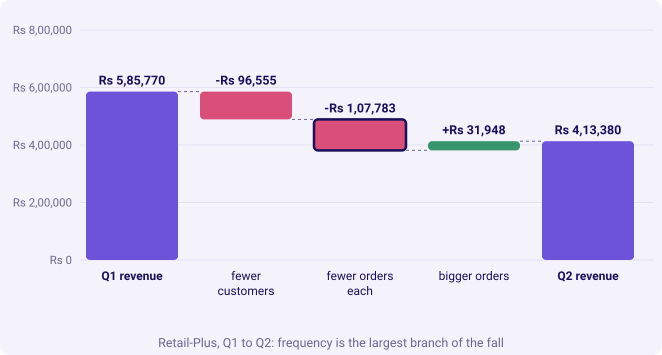

In [7]:
p = next(r for r in two if r["segment"] == "Retail-Plus")
raw = {x["quarter"]: x for x in kit.sql(
    "SELECT o.quarter, count(DISTINCT o.customer_id) AS c, count(*) AS n, sum(o.amount) AS r "
    "FROM orders o JOIN customers c USING (customer_id) WHERE c.segment = 'Retail-Plus' "
    "GROUP BY o.quarter ORDER BY o.quarter")}
c1, n1, r1 = int(raw["Q1"]["c"]), int(raw["Q1"]["n"]), float(raw["Q1"]["r"])
c2, n2, r2 = int(raw["Q2"]["c"]), int(raw["Q2"]["n"]), float(raw["Q2"]["r"])
step1 = c2 * (n1 / c1) * (r1 / n1)          # Q2 customers, Q1 frequency and order value
step2 = n2 * (r1 / n1)                      # Q2 customers and frequency, Q1 order value
moves = [("fewer customers", round(step1 - r1)), ("fewer orders each", round(step2 - step1)),
         ("bigger orders", round(r2 - step2))]
kit.bridge(("Q1 revenue", round(r1)), moves, end_label="Q2 revenue", lit=(1,), fmt=kit.rupees,
           title="Retail-Plus, Q1 to Q2: frequency is the largest branch of the fall")
kit.check("the three branches land exactly on Q2 revenue", round(r1) + sum(m for _, m in moves) == round(r2),
          kit.rupees(r2))
kit.check("frequency is the largest single fall", min(moves, key=lambda m: m[1])[0] == "fewer orders each")

The order of the steps changes the split slightly, and the bridge states the order it used:
customers first, then frequency, then order value. Frequency costs Rs 1.08 lakh of the Rs 1.72 lakh
fall, which is the Week 1 lever at warehouse scale. The book also shows fewer members buying at all,
which an extract of 22 members could not show.

## 3. The plausible wrong answer: an average that skips people without saying so

The head of Retail-Plus asks how average spend per member moved from Q1 to Q2. A hurried analyst
builds one row per member with a quarter's spend in each column, then averages the columns.

**Predict before you run.** A member who ordered in Q1 and not in Q2 gets which Q2 spend from
`sum(CASE WHEN quarter = 'Q2' THEN amount END)`: a) Rs 0; b) NULL, no value at all; c) their Q1
spend; d) an error?

In [8]:
print(Q["r3_member_spend_hurried"])

-- The question: how did average spend per Retail-Plus member move from Q1 to Q2? (The hurried version.)
WITH member AS (
    SELECT o.customer_id,
           sum(CASE WHEN o.quarter = 'Q1' THEN o.amount END) AS q1_spend,
           sum(CASE WHEN o.quarter = 'Q2' THEN o.amount END) AS q2_spend
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  c.segment = 'Retail-Plus'
    GROUP  BY o.customer_id
)
SELECT round(avg(q1_spend)) AS avg_q1_spend,
       round(avg(q2_spend)) AS avg_q2_spend,
       round(100 * (avg(q2_spend) - avg(q1_spend)) / avg(q1_spend), 1) AS change_pct
FROM   member;


In [9]:
hurried = kit.sql(Q["r3_member_spend_hurried"])[0]
kit.stats([(kit.rupees(hurried["avg_q1_spend"]), "Q1 spend per member", "the hurried average"),
           (kit.rupees(hurried["avg_q2_spend"]), "Q2 spend per member", "the hurried average"),
           (f"{float(hurried['change_pct']):.1f}%", "the change", "what the head would be told")],
          caption="The hurried reading, as it would reach the head of Retail-Plus")

**The plausible wrong answer.** Spend per member fell 15.5 percent, from Rs 6,437 to Rs 5,439: a
soft quarter, worth a reminder email. The head of Retail-Plus plans a light touch.

**Why it is wrong.** A `CASE` with no `ELSE` returns NULL, and `sum` of nothing but NULLs is NULL,
so a member with no Q2 order carries NULL, answer b. `avg` then skips NULLs without saying so: the
Q2 average divides by the members who bought in Q2 and drops the ones who stopped. The members the
head most needs to hear about have vanished from the denominator.

**The check that exposes it.** Count the members each average actually divides by. The mechanism
first, on three invented values that are not Kalpa data.

measure,value
avg(spend),150.0
count(*),3
count(spend),2
sum over all rows,100


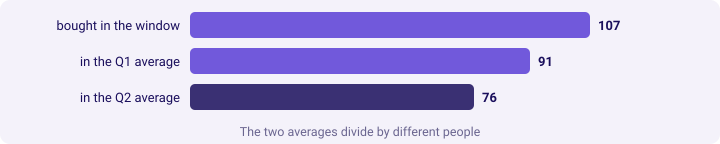

In [10]:
inv = kit.sql(Q["r3_invented_null"])[0]
kit.table(["measure", "value"], [("avg(spend)", float(inv["avg_spend"])), ("count(*)", inv["rows_in_table"]),
                                 ("count(spend)", inv["values_averaged"]), ("sum over all rows", int(inv["sum_over_rows"]))],
          caption="Invented values 100, NULL and 200: avg divides by 2, the table holds 3")
chk = kit.sql(Q["r3_member_spend_check"])[0]
kit.bars([("bought in the window", int(chk["members"])),
          ("in the Q1 average", int(chk["members_in_q1_average"])),
          ("in the Q2 average", int(chk["members_in_q2_average"]))],
         title="The two averages divide by different people", lit=(2,))
kit.check("avg over 100, NULL and 200 is 150", float(inv["avg_spend"]) == 150)
kit.check("the Q2 average silently drops 31 members", int(chk["members"]) - int(chk["members_in_q2_average"]) == 31,
          f"{chk['members']} members, {chk['members_in_q2_average']} averaged")

In [11]:
print(Q["r3_member_spend_fixed"])

-- The fix: a member who bought nothing in a quarter spent Rs 0 in it, said on purpose.
WITH member AS (
    SELECT o.customer_id,
           coalesce(sum(CASE WHEN o.quarter = 'Q1' THEN o.amount END), 0) AS q1_spend,
           coalesce(sum(CASE WHEN o.quarter = 'Q2' THEN o.amount END), 0) AS q2_spend
    FROM   orders o
    JOIN   customers c USING (customer_id)
    WHERE  c.segment = 'Retail-Plus'
    GROUP  BY o.customer_id
)
SELECT count(*)             AS members,
       round(avg(q1_spend)) AS avg_q1_spend,
       round(avg(q2_spend)) AS avg_q2_spend,
       round(100 * (avg(q2_spend) - avg(q1_spend)) / avg(q1_spend), 1) AS change_pct
FROM   member;


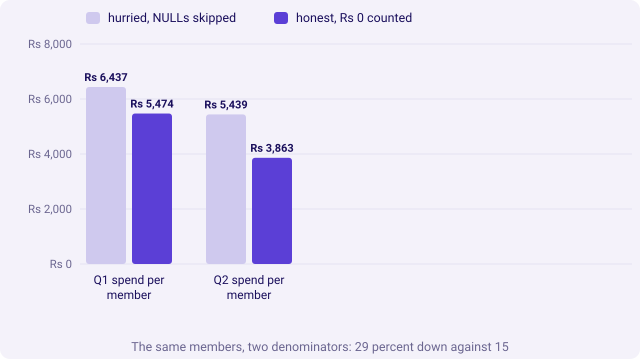

In [12]:
fixed = kit.sql(Q["r3_member_spend_fixed"])[0]
kit.columns(["Q1 spend per member", "Q2 spend per member"],
            [("hurried, NULLs skipped", [int(hurried["avg_q1_spend"]), int(hurried["avg_q2_spend"])]),
             ("honest, Rs 0 counted", [int(fixed["avg_q1_spend"]), int(fixed["avg_q2_spend"])])],
            title="The same members, two denominators: 29 percent down against 15", fmt=kit.rupees,
            width=640)
kit.check("the honest fall is 29.4 percent", float(fixed["change_pct"]) == -29.4, f"{fixed['change_pct']}")
kit.check("the honest average divides by all 107 members", int(fixed["members"]) == 107)

**The fix, and what it changed.** `coalesce(sum(...), 0)` states on purpose that a member who
bought nothing spent Rs 0, and the comment says the denominator is every member who bought in
either quarter. Spend per member fell 29.4 percent, from Rs 5,474 to Rs 3,863: nearly twice the
hurried 15.5 percent, and the same fall the segment's revenue shows, as it must when the members
are the same 107 people. The head's light touch becomes a retention problem.

## 4. The harder variant: the honest average for every segment

In [13]:
print(Q["r3_member_spend_by_segment"])

-- The harder variant: the same honest average for every segment, one row each.
WITH member AS (
    SELECT o.customer_id,
           c.segment,
           coalesce(sum(CASE WHEN o.quarter = 'Q1' THEN o.amount END), 0) AS q1_spend,
           coalesce(sum(CASE WHEN o.quarter = 'Q2' THEN o.amount END), 0) AS q2_spend
    FROM   orders o
    JOIN   customers c USING (customer_id)
    GROUP  BY o.customer_id, c.segment
)
SELECT segment,
       count(*)             AS members,
       round(avg(q1_spend)) AS avg_q1_spend,
       round(avg(q2_spend)) AS avg_q2_spend,
       round(100 * (avg(q2_spend) - avg(q1_spend)) / avg(q1_spend), 1) AS change_pct
FROM   member
GROUP  BY segment
ORDER  BY segment;


segment,members,avg_q1_spend,avg_q2_spend,change_pct
Business,39,"2,538,832","2,502,169",-1.4
Retail-Core,131,2848,2796,-1.8
Retail-Plus,107,5474,3863,-29.4
Student,24,1113,1490,33.9


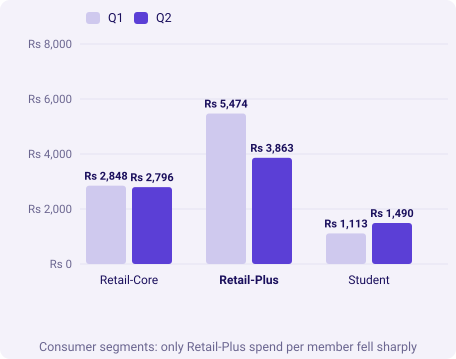

In [14]:
allseg = kit.sql(Q["r3_member_spend_by_segment"])
kit.sql_table(Q["r3_member_spend_by_segment"], caption="Spend per member, every member counted, per segment")
consumer = [r for r in allseg if r["segment"] != "Business"]
kit.columns([r["segment"] for r in consumer],
            [("Q1", [int(r["avg_q1_spend"]) for r in consumer]), ("Q2", [int(r["avg_q2_spend"]) for r in consumer])],
            title="Consumer segments: only Retail-Plus spend per member fell sharply", fmt=kit.rupees, lit=(1,))
kit.check("each segment's member change equals its revenue change",
          all(float(r["change_pct"]) == float(t["revenue_change_pct"])
              for r in allseg for t in two if t["segment"] == r["segment"]))

Business sits off this chart because its members spend lakhs, and one scale cannot show both. The
check proves the honest average is the revenue change in disguise, which is how an analyst knows
the denominator is right.

> **Kavya's review.** Three named steps, each one line of comment, and a denominator you can say
> aloud. When a number comes out of an average, say who is in it. That is the difference between a
> 15 percent wobble and a 29 percent problem.

### In the interview

**[D] A stakeholder's analyst must audit your query; what changes in how you write it, and what
would you refuse to compute in a notebook?** "I write it to be read: one named step per idea as a
CTE, a comment on each saying what it computes and what the denominator is, explicit numeric
division, an `ORDER BY` on every list, and a check query beside it that adds the groups back to the
total. I refuse to compute the reported KPI in a notebook on an export, because the analyst cannot
rerun it against the book and a mistyped cell leaves no trace. The notebook is where I explore;
the query is what I hand over."

**[F] Why a CTE rather than a subquery?** "Both compute the same thing. A CTE names the step and
puts it first, so the query reads top to bottom in the order the logic runs, and a step can be used
twice. A subquery is fine for a one-off total, like a share's denominator."

**Follow-up an interviewer adds: AVG and NULLs.** "Aggregates skip NULLs, and `count(*)` does not,
so `avg(x)` equals `sum(x) / count(x)`. Whenever a NULL means zero in the business, I say so with
`coalesce`, and whenever it means unknown, I report how many were unknown."

### Depth: the monthly shape of the Retail-Plus fall

A quarter hides its months. Grouping by month shows whether the fall is one bad month or a slide.

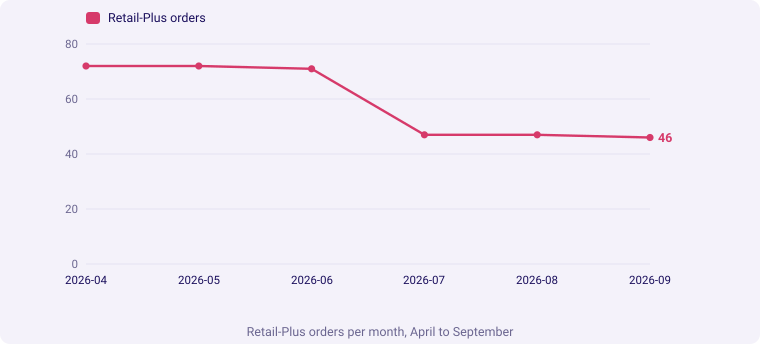

In [15]:
months = kit.sql("SELECT to_char(o.order_date, 'YYYY-MM') AS month, count(*) AS orders "
                 "FROM orders o JOIN customers c USING (customer_id) WHERE c.segment = 'Retail-Plus' "
                 "GROUP BY month ORDER BY month")
kit.line([r["month"] for r in months], [("Retail-Plus orders", [int(r["orders"]) for r in months], "bad")],
         title="Retail-Plus orders per month, April to September")
kit.check("six months across the two quarters", len(months) == 6)

In [16]:
kit.check_summary()
print("Next: the afternoon's case, the Monday suite, six queries Anand's analyst will audit.")

Next: the afternoon's case, the Monday suite, six queries Anand's analyst will audit.
